In [ ]:
# =================================================================
# nagel.ipynb — Phase 3 critique (Nagel 2025)
# Claim: the "virtue" is volatility-timed momentum in disguise. In short
# windows the RFF timing forecast reduces to a recency-weighted, vol-scaled
# bet on recent returns. Counter-spec: build a plain vol-timed momentum
# strategy (NO predictors, NO RFF), aligned to the SAME bet horizon as KMZ,
# and measure how much of the KMZ Sharpe it mechanically explains.
# =================================================================
from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

KMZ    = "/content/drive/MyDrive/Summer Research/kmz"
DEBATE = "/content/drive/MyDrive/Summer Research/debate"
MASTER_SEED = 42

# --- engine copied from kmz_pipeline.ipynb — keep in sync ---
def make_rff(G, n_pairs, gamma=2.0, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((n_pairs, G.shape[1])).T   # draw j is the same no matter what n_pairs is
    proj = gamma * (G @ W)
    S = np.empty((G.shape[0], 2 * n_pairs))
    S[:, 0::2] = np.sin(proj)                          # sin/cos interleaved, so the first P columns are P/2 full pairs
    S[:, 1::2] = np.cos(proj)
    return S

# --- sanity check: first P columns must be P/2 sin/cos pairs, independent of n_pairs ---
_G = np.random.default_rng(1).standard_normal((5, 15))
assert np.allclose(make_rff(_G, n_pairs=4, seed=0), make_rff(_G, n_pairs=100, seed=0)[:, :8]), "make_rff is the old version"

def ridge_forecast_dual(S_tr, R_tr, S_t, z):
    T = S_tr.shape[0]
    K = (S_tr @ S_tr.T) / T
    a = np.linalg.solve(K + z*np.eye(T), R_tr/T)
    return float(S_t @ (S_tr.T @ a))

def run_oos_nested(S_full, R, P, T, z):
    assert P % 2 == 0, "P must be even so no sin/cos pair is split"
    S_all = S_full[:, :P]; N = len(R); fc, sr = [], []
    for t in range(T, N):
        S_tr, R_tr = S_all[t-T:t], R[t-T:t]
        sd = S_tr.std(axis=0); sd[sd==0]=1.0
        f = ridge_forecast_dual(S_tr/sd, R_tr, S_all[t]/sd, z)
        fc.append(f); sr.append(f*R[t])
    return np.array(fc), np.array(sr)

def sharpe(x):
    return x.mean()/x.std()*np.sqrt(12)

Mounted at /content/drive


In [ ]:
predictors = ["dp","dy","ep","de","svar","bm","ntis","tbl","lty","ltr",
              "tms","dfy","dfr","infl","mktret_lag"]
panel = pd.read_parquet(f"{KMZ}/predictors.parquet").sort_values("date").reset_index(drop=True)
panel["target"] = panel["excess_ret"].shift(-1)          # KMZ target: return_{t+1} on row t

def exp_std(s, mp=36):
    return s / s.expanding(min_periods=mp).std().shift(1)

std = panel.copy()
for c in predictors: std[c] = exp_std(panel[c])
std = std.dropna(subset=predictors+["target"]).reset_index(drop=True)

G = std[predictors].to_numpy()
R = std["target"].to_numpy()                 # aligned next-month excess return (KMZ target)
ret_series = std["excess_ret"].to_numpy()    # contemporaneous excess return (for momentum)
dates = std["date"].to_numpy()
print("data ready:", G.shape, R.shape)

data ready: (1152, 15) (1152,)


In [ ]:
# =================================================================
# Vol-timed momentum benchmark — NO predictors, NO RFF.
# Position at t uses returns through t-1 (causal), applied to R[t]
# (the KMZ next-month target), so the bet horizon EXACTLY matches KMZ:
# both form the position from info through t-1 and earn the t->t+1 return.
# =================================================================
def vol_timed_momentum(ret_contemp, R_target, mom_window=12, vol_window=12):
    """
    ret_contemp : contemporaneous excess return (return realized during month t)
    R_target    : aligned next-month return (R[t] = return over t -> t+1), KMZ's target
    position at t = (trailing mean return) / (trailing vol), using data through t-1,
    earned return = position * R_target[t]  -> same horizon as the KMZ strategy.
    """
    N = len(R_target)
    start = max(mom_window, vol_window)
    strat = []
    for t in range(start, N):
        mom = ret_contemp[t-mom_window:t].mean()                 # info through t-1
        vol = np.sqrt((ret_contemp[t-vol_window:t]**2).mean())   # info through t-1
        pos = mom / (vol + 1e-8)
        strat.append(pos * R_target[t])                          # earn t->t+1 return
    return np.array(strat), start

mom_strat, mom_start = vol_timed_momentum(ret_series, R)
mom_sharpe = sharpe(mom_strat)
print(f"Vol-timed momentum Sharpe (aligned, no predictors/RFF): {mom_sharpe:.3f}")
print(f"months: {len(mom_strat)}  ({pd.Timestamp(dates[mom_start]).date()} onward)")

Vol-timed momentum Sharpe (aligned, no predictors/RFF): 0.283
months: 1140  (1930-12-01 onward)


In [ ]:
# Compare like-for-like: momentum is a single deterministic run, so compare it to a
# SINGLE-draw KMZ run (not the 20-draw average), over the same annualization.
S_full = make_rff(G, n_pairs=6000, gamma=2.0, seed=MASTER_SEED*100000 + 0)
_, kmz_strat = run_oos_nested(S_full, R, P=12000, T=12, z=1e-3)   # highest complexity, 1 draw
kmz_sharpe_1draw = sharpe(kmz_strat)

# align to the same months (both should cover the overlapping period)
print(f"momentum Sharpe          : {mom_sharpe:.3f}  (n={len(mom_strat)})")
print(f"KMZ P=12000 single-draw  : {kmz_sharpe_1draw:.3f}  (n={len(kmz_strat)})")
kmz_avg_12000 = pd.read_parquet(f"{KMZ}/kmz_sweep_avg.parquet").set_index("P").loc[12000, "sharpe"]
print(f"KMZ P=12000 20-draw avg  : {kmz_avg_12000:.3f}  (from Phase 2)")

momentum Sharpe          : 0.283  (n=1140)
KMZ P=12000 single-draw  : 0.145  (n=1140)
KMZ P=12000 20-draw avg  : 0.147  (from Phase 2)


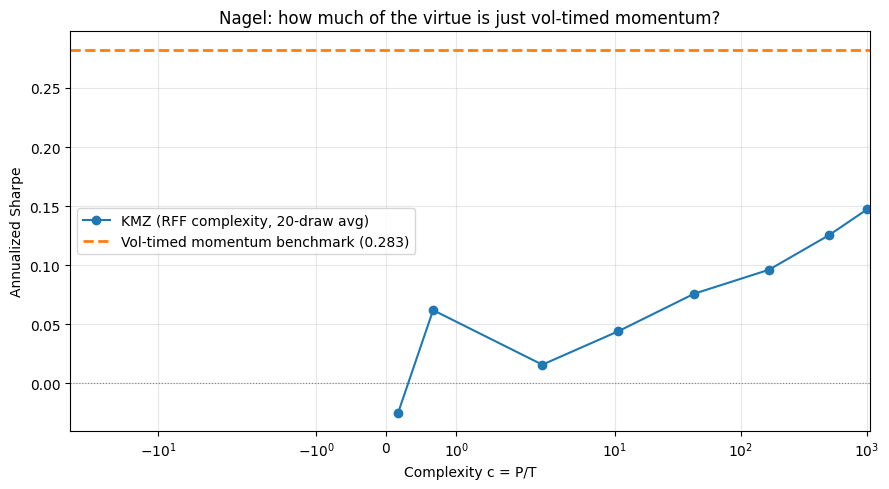

In [ ]:
kmz = pd.read_parquet(f"{KMZ}/kmz_sweep_avg.parquet")

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(kmz["complexity"], kmz["sharpe"], "o-", label="KMZ (RFF complexity, 20-draw avg)")
ax.axhline(mom_sharpe, color="C1", ls="--", lw=2,
           label=f"Vol-timed momentum benchmark ({mom_sharpe:.3f})")
ax.set_xscale("symlog"); ax.axhline(0, color="grey", lw=.8, ls=":")
ax.set_xlabel("Complexity c = P/T"); ax.set_ylabel("Annualized Sharpe")
ax.set_title("Nagel: how much of the virtue is just vol-timed momentum?")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
fig.savefig(f"{DEBATE}/nagel_momentum.png", dpi=150, bbox_inches="tight")

In [6]:
# =================================================================
# Spanning regression — does momentum EXPLAIN the KMZ returns?
# A higher momentum Sharpe alone doesn't show KMZ is momentum in disguise.
# Regress the KMZ P=12000 single-draw strategy returns on the momentum
# strategy returns (same 1,140 months). Nagel predicts high correlation
# and an insignificant alpha. Newey-West (12 lags) standard errors.
# =================================================================
import statsmodels.api as sm

assert len(kmz_strat) == len(mom_strat)          # both start at t=12 → same months
res = sm.OLS(kmz_strat, sm.add_constant(mom_strat)).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
resid_ir = res.params[0] / res.resid.std() * np.sqrt(12)   # annualized Sharpe of the unexplained part

print(f"corr(KMZ, momentum)   : {np.corrcoef(kmz_strat, mom_strat)[0,1]:.3f}")
print(f"R² of KMZ on momentum : {res.rsquared:.3f}")
print(f"beta on momentum      : {res.params[1]:.3f}  (t={res.tvalues[1]:.2f})")
print(f"alpha (monthly)       : {res.params[0]:.2e}  (t={res.tvalues[0]:.2f})")
print(f"alpha info ratio (ann): {resid_ir:.3f}   vs KMZ single-draw Sharpe {kmz_sharpe_1draw:.3f}")


corr(KMZ, momentum)   : 0.206
R² of KMZ on momentum : 0.042
beta on momentum      : 0.004  (t=2.21)
alpha (monthly)       : 1.04e-05  (t=0.77)
alpha info ratio (ann): 0.088   vs KMZ single-draw Sharpe 0.145
